#### Importing libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

# import pandas and alias it as pd
import pandas as pd

# import operating system
import os

# try to import yahoo finance and alias it as yf
try:
    import yfinance as yf
# if it isnt installed
except ModuleNotFoundError:
    # install it
    ! pip install yfinance
    # import yfinance and alias it as yf
    import yfinance as yf

# import plotting library and alias it as plt
import matplotlib.pyplot as plt

# library for progress bar
from tqdm import tqdm

#### Make an output directory

In [2]:
str_dirname_output = './output'
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

#### Get stock data

In [3]:
# ticker name
str_ticker_name = 'AAPL'
# last n days
int_n_days = 100
# format a string
print(f'You want to pull {str_ticker_name} stocks for the last {int_n_days} days')

You want to pull AAPL stocks for the last 100 days


In [4]:
# initialize class
cls_ticker = yf.Ticker(str_ticker_name)
# get last n days
df = cls_ticker.history(period=f'{int_n_days}d')

# save
str_filename = f'df_{str_ticker_name}.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=True)

# show
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-03 00:00:00-05:00,242.774368,243.592387,241.307905,242.774368,40244100,0.0,0.0
2025-01-06 00:00:00-05:00,243.722074,246.734810,242.614744,244.410416,45045600,0.0,0.0
2025-01-07 00:00:00-05:00,242.395272,244.959095,240.769205,241.627136,40856000,0.0,0.0
2025-01-08 00:00:00-05:00,241.337815,243.123515,239.472320,242.115936,37628900,0.0,0.0
2025-01-10 00:00:00-05:00,239.432413,239.582061,232.439288,236.280029,61710900,0.0,0.0
...,...,...,...,...,...,...,...
2025-05-22 00:00:00-04:00,200.710007,202.750000,199.699997,201.360001,46742400,0.0,0.0
2025-05-23 00:00:00-04:00,193.669998,197.699997,193.460007,195.270004,78432900,0.0,0.0
2025-05-27 00:00:00-04:00,198.300003,200.740005,197.429993,200.210007,56288500,0.0,0.0


#### Make this into a function

In [5]:
def get_stock_values(str_ticker_name, int_n_days, str_dirname_output):
    # initialize class
    cls_ticker = yf.Ticker(str_ticker_name)
    # get last n days
    df = cls_ticker.history(period=f'{int_n_days}d')
    
    # save
    str_filename = f'df_{str_ticker_name}.csv'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    df.to_csv(str_local_path, index=True)
    
    # return
    return df

#### Execute function

In [6]:
# get stocks using a function
df = get_stock_values(
    str_ticker_name=str_ticker_name,
    int_n_days=int_n_days,
    str_dirname_output=str_dirname_output,
)
# show
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-03 00:00:00-05:00,242.774368,243.592387,241.307905,242.774368,40244100,0.0,0.0
2025-01-06 00:00:00-05:00,243.722074,246.734810,242.614744,244.410416,45045600,0.0,0.0
2025-01-07 00:00:00-05:00,242.395272,244.959095,240.769205,241.627136,40856000,0.0,0.0
2025-01-08 00:00:00-05:00,241.337815,243.123515,239.472320,242.115936,37628900,0.0,0.0
2025-01-10 00:00:00-05:00,239.432413,239.582061,232.439288,236.280029,61710900,0.0,0.0
...,...,...,...,...,...,...,...
2025-05-22 00:00:00-04:00,200.710007,202.750000,199.699997,201.360001,46742400,0.0,0.0
2025-05-23 00:00:00-04:00,193.669998,197.699997,193.460007,195.270004,78432900,0.0,0.0
2025-05-27 00:00:00-04:00,198.300003,200.740005,197.429993,200.210007,56288500,0.0,0.0


#### Plot it

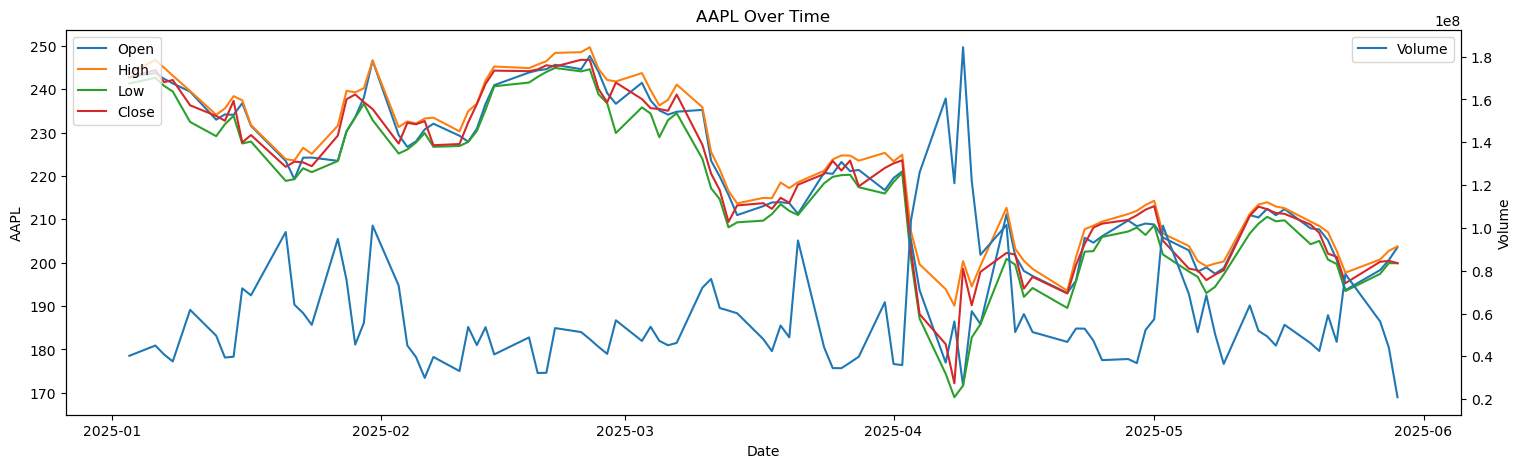

In [7]:
fig, ax = plt.subplots(figsize=(18,5))
# title
str_title = f'{str_ticker_name} Over Time'
ax.set_title(str_title)
ax.set_xlabel('Date')
ax.set_ylabel(str_ticker_name)
# plot open, high, low, and close using a loop
list_cols = [
    'Open',
    'High',
    'Low',
    'Close',
]
for col in list_cols:
    ax.plot(df.index.to_numpy(), df[col].to_numpy(), label=col)

# legend
ax.legend(loc='upper left')

# plot volume on second y
ax2 = ax.twinx()
ax2.set_ylabel('Volume')
ax2.plot(df.index.to_numpy(), df['Volume'].to_numpy(), label='Volume')

# legend
ax2.legend(loc='upper right')

# save
str_filename = f'plt_{str_ticker_name}.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Make this into a function

In [8]:
def plot_stock_values(str_ticker_name, df, str_dirname_output):
    fig, ax = plt.subplots(figsize=(18,5))
    # title
    str_title = f'{str_ticker_name} Over Time'
    ax.set_title(str_title)
    ax.set_xlabel('Date')
    ax.set_ylabel(str_ticker_name)
    # plot open, high, low, and close using a loop
    list_cols = [
        'Open',
        'High',
        'Low',
        'Close',
    ]
    for col in list_cols:
        ax.plot(df.index.to_numpy(), df[col].to_numpy(), label=col)

    # legend
    ax.legend(loc='upper left')

    # plot volume on second y
    ax2 = ax.twinx()
    ax2.set_ylabel('Volume')
    ax2.plot(df.index.to_numpy(), df['Volume'].to_numpy(), label='Volume')

    # legend
    ax2.legend(loc='upper right')

    # save
    str_filename = f'plt_{str_ticker_name}.png'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')

    # show
    plt.show()

#### Execute function

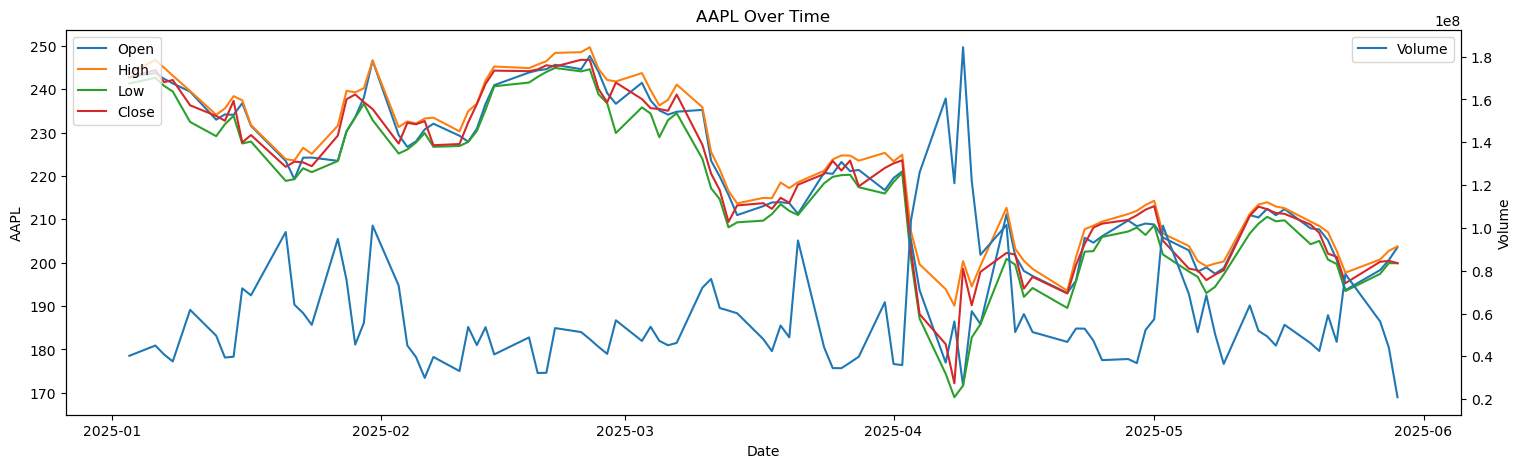

In [9]:
plot_stock_values(
    str_ticker_name=str_ticker_name,
    df=df,
    str_dirname_output=str_dirname_output,
)

#### Create class

In [10]:
class PullAndPlotStock:
    # init
    def __init__(self, str_ticker_name, int_n_days, str_dirname_output):
        self.str_ticker_name = str_ticker_name
        self.int_n_days = int_n_days
        self.str_dirname_output = str_dirname_output
    # method to pull stocks
    def get_stock_values(self):
        # initialize class
        cls_ticker = yf.Ticker(self.str_ticker_name)
        # get last n days
        df = cls_ticker.history(period=f'{self.int_n_days}d')

        # save
        str_filename = f'df_{self.str_ticker_name}.csv'
        str_local_path = f'{self.str_dirname_output}/{str_filename}'
        df.to_csv(str_local_path, index=True)

        # save to object
        self.df = df
        # return
        return self
    # method to plot stocks
    def plot_stock_values(self):
        fig, ax = plt.subplots(figsize=(18,5))
        # title
        str_title = f'{self.str_ticker_name} Over Time'
        ax.set_title(str_title)
        ax.set_xlabel('Date')
        ax.set_ylabel(self.str_ticker_name)
        # plot open, high, low, and close using a loop
        list_cols = [
            'Open',
            'High',
            'Low',
            'Close',
        ]
        for col in list_cols:
            ax.plot(self.df.index.to_numpy(), self.df[col].to_numpy(), label=col)

        # legend
        ax.legend(loc='upper left')

        # plot volume on second y
        ax2 = ax.twinx()
        ax2.set_ylabel('Volume')
        ax2.plot(self.df.index.to_numpy(), self.df['Volume'].to_numpy(), label='Volume')

        # legend
        ax2.legend(loc='upper right')

        # save
        str_filename = f'plt_{self.str_ticker_name}.png'
        str_local_path = f'{self.str_dirname_output}/{str_filename}'
        plt.savefig(str_local_path, bbox_inches='tight')

        # show
        plt.show()

#### Initialize class

In [11]:
cls_pull_and_plot = PullAndPlotStock(
    str_ticker_name=str_ticker_name,
    int_n_days=int_n_days,
    str_dirname_output=str_dirname_output,
)

#### Get stocks and plot stocks

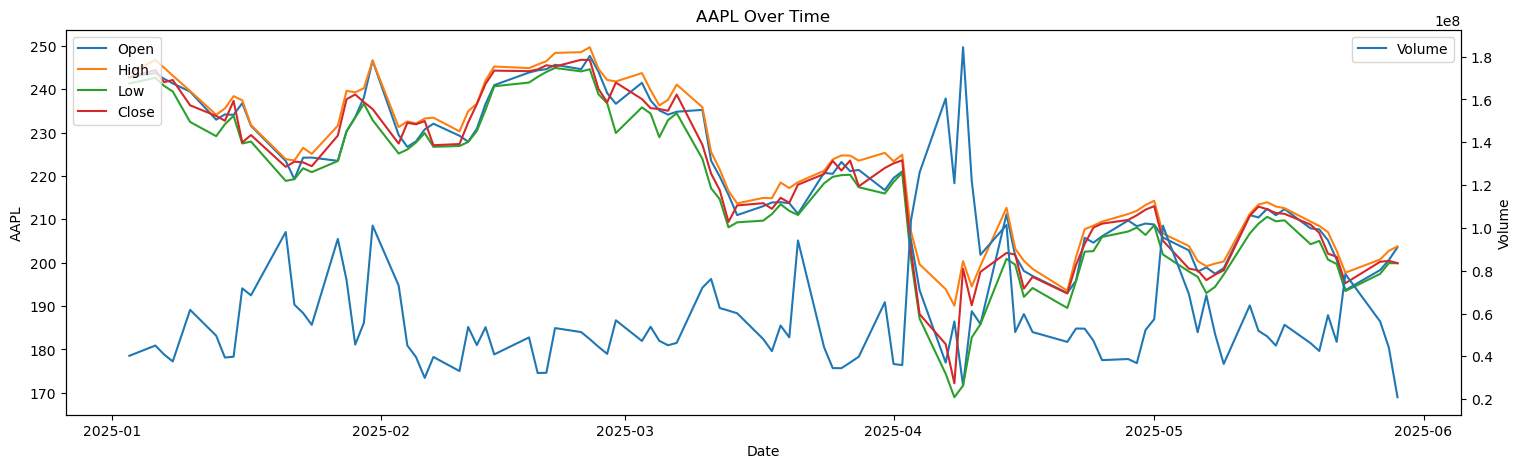

In [12]:
# get stocks
cls_pull_and_plot.get_stock_values()
# plot
cls_pull_and_plot.plot_stock_values()

#### Pull and plot a different stock

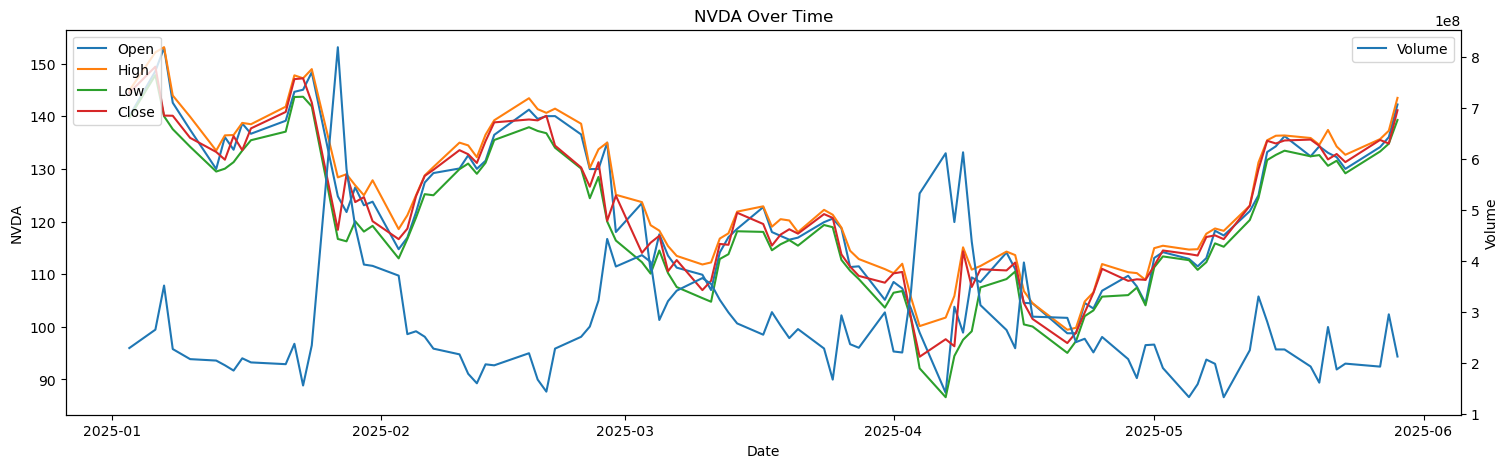

In [13]:
# ticker name
str_ticker_name = 'NVDA'
# initialize
cls_pull_and_plot = PullAndPlotStock(
    str_ticker_name=str_ticker_name,
    int_n_days=int_n_days,
    str_dirname_output=str_dirname_output,
)
# get stocks
cls_pull_and_plot.get_stock_values()
# plot
cls_pull_and_plot.plot_stock_values()

#### Execute in a loop

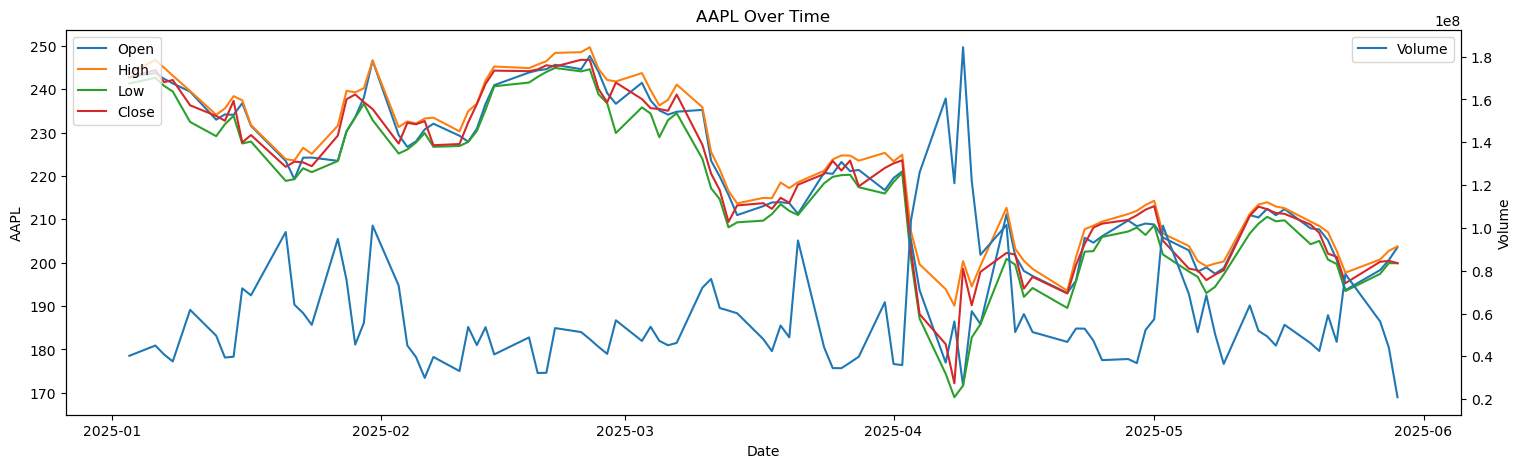

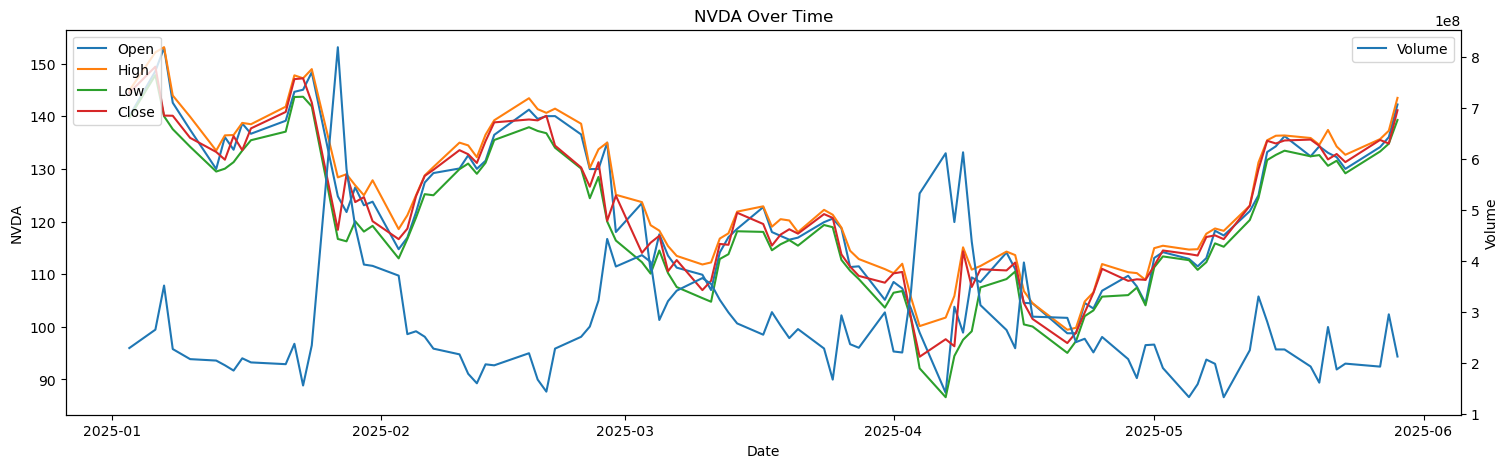

In [14]:
list_str_ticker_name = [
    'AAPL',
    'NVDA',
]
for str_ticker_name in list_str_ticker_name:
    # initialize
    cls_pull_and_plot = PullAndPlotStock(
        str_ticker_name=str_ticker_name,
        int_n_days=int_n_days,
        str_dirname_output=str_dirname_output,
    )
    # get stocks
    cls_pull_and_plot.get_stock_values()
    # plot
    cls_pull_and_plot.plot_stock_values()

#### Import AAPL

In [15]:
str_ticker_name = 'AAPL'
# import
str_filename = f'df_{str_ticker_name}.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
# read csv
df_aapl = pd.read_csv(str_local_path)
# show
df_aapl

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2025-01-03 00:00:00-05:00,242.774368,243.592387,241.307905,242.774368,40244100,0.0,0.0
1,2025-01-06 00:00:00-05:00,243.722074,246.734810,242.614744,244.410416,45045600,0.0,0.0
2,2025-01-07 00:00:00-05:00,242.395272,244.959095,240.769205,241.627136,40856000,0.0,0.0
3,2025-01-08 00:00:00-05:00,241.337815,243.123515,239.472320,242.115936,37628900,0.0,0.0
4,2025-01-10 00:00:00-05:00,239.432413,239.582061,232.439288,236.280029,61710900,0.0,0.0
...,...,...,...,...,...,...,...,...
95,2025-05-22 00:00:00-04:00,200.710007,202.750000,199.699997,201.360001,46742400,0.0,0.0
96,2025-05-23 00:00:00-04:00,193.669998,197.699997,193.460007,195.270004,78432900,0.0,0.0
97,2025-05-27 00:00:00-04:00,198.300003,200.740005,197.429993,200.210007,56288500,0.0,0.0
98,2025-05-28 00:00:00-04:00,200.589996,202.729996,199.899994,200.419998,44158300,0.0,0.0


#### Rename columns

In [16]:
# remove Date using list comprehension
list_cols = [col for col in df_aapl.columns if col != 'Date']
# create renaming dictionary
dict_rename = {col: f'{col}_{str_ticker_name}' for col in list_cols}

# print this
print('Renaming dictionary:')
print(dict_rename)

# rename
df_aapl.rename(columns=dict_rename, inplace=True)

# show
df_aapl

Renaming dictionary:
{'Open': 'Open_AAPL', 'High': 'High_AAPL', 'Low': 'Low_AAPL', 'Close': 'Close_AAPL', 'Volume': 'Volume_AAPL', 'Dividends': 'Dividends_AAPL', 'Stock Splits': 'Stock Splits_AAPL'}


,Date,Open_AAPL,High_AAPL,Low_AAPL,Close_AAPL,Volume_AAPL,Dividends_AAPL,Stock Splits_AAPL
0,2025-01-03 00:00:00-05:00,242.774368,243.592387,241.307905,242.774368,40244100,0.0,0.0
1,2025-01-06 00:00:00-05:00,243.722074,246.734810,242.614744,244.410416,45045600,0.0,0.0
2,2025-01-07 00:00:00-05:00,242.395272,244.959095,240.769205,241.627136,40856000,0.0,0.0
3,2025-01-08 00:00:00-05:00,241.337815,243.123515,239.472320,242.115936,37628900,0.0,0.0
4,2025-01-10 00:00:00-05:00,239.432413,239.582061,232.439288,236.280029,61710900,0.0,0.0
...,...,...,...,...,...,...,...,...
95,2025-05-22 00:00:00-04:00,200.710007,202.750000,199.699997,201.360001,46742400,0.0,0.0
96,2025-05-23 00:00:00-04:00,193.669998,197.699997,193.460007,195.270004,78432900,0.0,0.0
97,2025-05-27 00:00:00-04:00,198.300003,200.740005,197.429993,200.210007,56288500,0.0,0.0
98,2025-05-28 00:00:00-04:00,200.589996,202.729996,199.899994,200.419998,44158300,0.0,0.0


#### Do the same with NVIDIA

In [17]:
str_ticker_name = 'NVDA'
# import
str_filename = f'df_{str_ticker_name}.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
# read csv
df_nvda = pd.read_csv(str_local_path)
# show
df_nvda

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2025-01-03 00:00:00-05:00,139.997114,144.886664,139.717141,144.456711,229322500,0.0,0.0
1,2025-01-06 00:00:00-05:00,148.576325,152.146004,147.806407,149.416245,265377400,0.0,0.0
2,2025-01-07 00:00:00-05:00,153.015919,153.115916,139.997113,140.127106,351782200,0.0,0.0
3,2025-01-08 00:00:00-05:00,142.566896,143.936766,137.547354,140.097122,227349900,0.0,0.0
4,2025-01-10 00:00:00-05:00,137.437358,139.907133,134.207660,135.897507,207602500,0.0,0.0
...,...,...,...,...,...,...,...,...
95,2025-05-22 00:00:00-04:00,132.229996,134.250000,131.550003,132.830002,187344000,0.0,0.0
96,2025-05-23 00:00:00-04:00,130.000000,132.679993,129.160004,131.289993,198821300,0.0,0.0
97,2025-05-27 00:00:00-04:00,134.149994,135.660004,133.309998,135.500000,192953600,0.0,0.0
98,2025-05-28 00:00:00-04:00,136.029999,137.250000,134.789993,134.809998,295482900,0.0,0.0


#### Rename columns

In [18]:
# remove Date using list comprehension
list_cols = [col for col in df_nvda.columns if col != 'Date']
# create renaming dictionary
dict_rename = {col: f'{col}_{str_ticker_name}' for col in list_cols}

# print this
print('Renaming dictionary:')
print(dict_rename)

# rename
df_nvda.rename(columns=dict_rename, inplace=True)

# show
df_nvda

Renaming dictionary:
{'Open': 'Open_NVDA', 'High': 'High_NVDA', 'Low': 'Low_NVDA', 'Close': 'Close_NVDA', 'Volume': 'Volume_NVDA', 'Dividends': 'Dividends_NVDA', 'Stock Splits': 'Stock Splits_NVDA'}


,Date,Open_NVDA,High_NVDA,Low_NVDA,Close_NVDA,Volume_NVDA,Dividends_NVDA,Stock Splits_NVDA
0,2025-01-03 00:00:00-05:00,139.997114,144.886664,139.717141,144.456711,229322500,0.0,0.0
1,2025-01-06 00:00:00-05:00,148.576325,152.146004,147.806407,149.416245,265377400,0.0,0.0
2,2025-01-07 00:00:00-05:00,153.015919,153.115916,139.997113,140.127106,351782200,0.0,0.0
3,2025-01-08 00:00:00-05:00,142.566896,143.936766,137.547354,140.097122,227349900,0.0,0.0
4,2025-01-10 00:00:00-05:00,137.437358,139.907133,134.207660,135.897507,207602500,0.0,0.0
...,...,...,...,...,...,...,...,...
95,2025-05-22 00:00:00-04:00,132.229996,134.250000,131.550003,132.830002,187344000,0.0,0.0
96,2025-05-23 00:00:00-04:00,130.000000,132.679993,129.160004,131.289993,198821300,0.0,0.0
97,2025-05-27 00:00:00-04:00,134.149994,135.660004,133.309998,135.500000,192953600,0.0,0.0
98,2025-05-28 00:00:00-04:00,136.029999,137.250000,134.789993,134.809998,295482900,0.0,0.0


#### Join on date

In [19]:
df = pd.merge(
    left=df_aapl,
    right=df_nvda,
    on='Date',
    how='left',
)
# show
df

,Date,Open_AAPL,High_AAPL,Low_AAPL,Close_AAPL,Volume_AAPL,Dividends_AAPL,Stock Splits_AAPL,Open_NVDA,High_NVDA,Low_NVDA,Close_NVDA,Volume_NVDA,Dividends_NVDA,Stock Splits_NVDA
0,2025-01-03 00:00:00-05:00,242.774368,243.592387,241.307905,242.774368,40244100,0.0,0.0,139.997114,144.886664,139.717141,144.456711,229322500,0.0,0.0
1,2025-01-06 00:00:00-05:00,243.722074,246.734810,242.614744,244.410416,45045600,0.0,0.0,148.576325,152.146004,147.806407,149.416245,265377400,0.0,0.0
2,2025-01-07 00:00:00-05:00,242.395272,244.959095,240.769205,241.627136,40856000,0.0,0.0,153.015919,153.115916,139.997113,140.127106,351782200,0.0,0.0
3,2025-01-08 00:00:00-05:00,241.337815,243.123515,239.472320,242.115936,37628900,0.0,0.0,142.566896,143.936766,137.547354,140.097122,227349900,0.0,0.0
4,2025-01-10 00:00:00-05:00,239.432413,239.582061,232.439288,236.280029,61710900,0.0,0.0,137.437358,139.907133,134.207660,135.897507,207602500,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2025-05-22 00:00:00-04:00,200.710007,202.750000,199.699997,201.360001,46742400,0.0,0.0,132.229996,134.250000,131.550003,132.830002,187344000,0.0,0.0
96,2025-05-23 00:00:00-04:00,193.669998,197.699997,193.460007,195.270004,78432900,0.0,0.0,130.000000,132.679993,129.160004,131.289993,198821300,0.0,0.0
97,2025-05-27 00:00:00-04:00,198.300003,200.740005,197.429993,200.210007,56288500,0.0,0.0,134.149994,135.660004,133.309998,135.500000,192953600,0.0,0.0
98,2025-05-28 00:00:00-04:00,200.589996,202.729996,199.899994,200.419998,44158300,0.0,0.0,136.029999,137.250000,134.789993,134.809998,295482900,0.0,0.0


#### Set date as index

In [20]:
# make a datetime
df['Date'] = pd.to_datetime(df['Date'])
# set index
df.set_index('Date', inplace=True)
# show
df

,Open_AAPL,High_AAPL,Low_AAPL,Close_AAPL,Volume_AAPL,Dividends_AAPL,Stock Splits_AAPL,Open_NVDA,High_NVDA,Low_NVDA,Close_NVDA,Volume_NVDA,Dividends_NVDA,Stock Splits_NVDA
Date,,,,,,,,,,,,,,
2025-01-03 00:00:00-05:00,242.774368,243.592387,241.307905,242.774368,40244100,0.0,0.0,139.997114,144.886664,139.717141,144.456711,229322500,0.0,0.0
2025-01-06 00:00:00-05:00,243.722074,246.734810,242.614744,244.410416,45045600,0.0,0.0,148.576325,152.146004,147.806407,149.416245,265377400,0.0,0.0
2025-01-07 00:00:00-05:00,242.395272,244.959095,240.769205,241.627136,40856000,0.0,0.0,153.015919,153.115916,139.997113,140.127106,351782200,0.0,0.0
2025-01-08 00:00:00-05:00,241.337815,243.123515,239.472320,242.115936,37628900,0.0,0.0,142.566896,143.936766,137.547354,140.097122,227349900,0.0,0.0
2025-01-10 00:00:00-05:00,239.432413,239.582061,232.439288,236.280029,61710900,0.0,0.0,137.437358,139.907133,134.207660,135.897507,207602500,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-22 00:00:00-04:00,200.710007,202.750000,199.699997,201.360001,46742400,0.0,0.0,132.229996,134.250000,131.550003,132.830002,187344000,0.0,0.0
2025-05-23 00:00:00-04:00,193.669998,197.699997,193.460007,195.270004,78432900,0.0,0.0,130.000000,132.679993,129.160004,131.289993,198821300,0.0,0.0
2025-05-27 00:00:00-04:00,198.300003,200.740005,197.429993,200.210007,56288500,0.0,0.0,134.149994,135.660004,133.309998,135.500000,192953600,0.0,0.0


#### Plot open for AAPL and NVDA

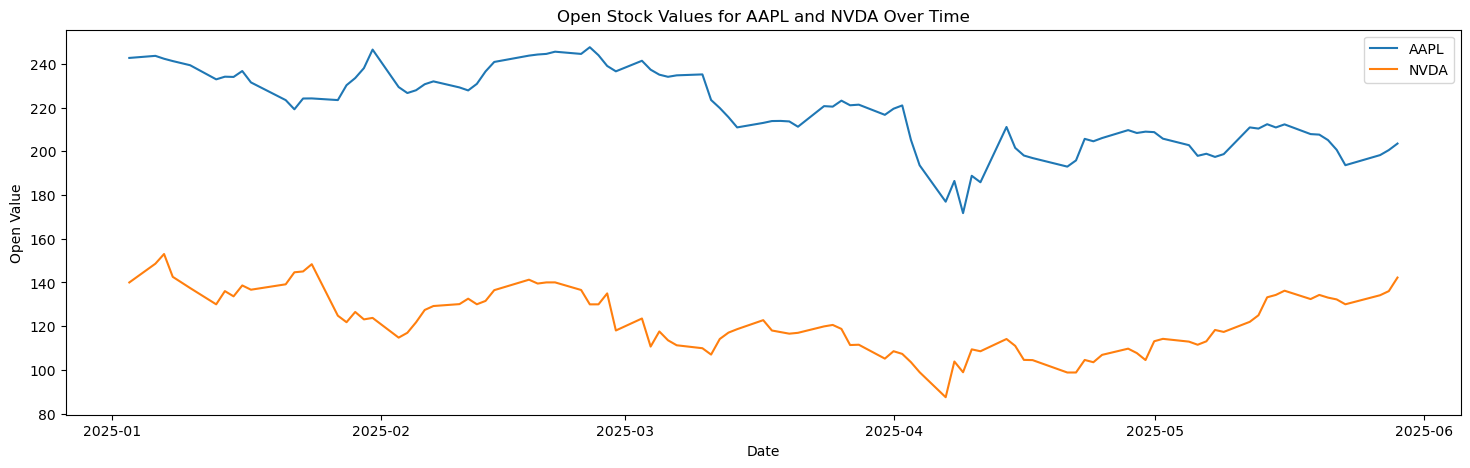

In [21]:
# create ax
fig, ax = plt.subplots(figsize=(18,5))

# title
ax.set_title('Open Stock Values for AAPL and NVDA Over Time')
# x label
ax.set_xlabel('Date')
# y label
ax.set_ylabel('Open Value')

# plot AAPL
ax.plot(df.index.to_numpy(), df['Open_AAPL'].to_numpy(), label='AAPL')
# plot NVDA
ax.plot(df.index.to_numpy(), df['Open_NVDA'].to_numpy(), label='NVDA')

# save
str_filename = 'plt_AAPL_NVDA.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# legend
ax.legend()

# show
plt.show()

#### Get descriptive statistics

In [22]:
list_cols = [
    'Open_AAPL',
    'Open_NVDA',
]
list_dict_row = []
# make a progress bar
for col in tqdm(list_cols):
    # min
    flt_min = df[col].min()
    # max
    flt_max = df[col].max()
    # mean
    flt_mn = df[col].mean()
    # sd
    flt_sd = df[col].std()
    # mdn
    flt_mdn = df[col].median()
    # dictionary as a row
    dict_row = {
        'column': col,
        'min': flt_min,
        'max': flt_max,
        'mean': flt_mn,
        'sd': flt_sd,
        'median': flt_mdn,
    }
    # append
    list_dict_row.append(dict_row)
# make into df
df_tmp = pd.DataFrame(list_dict_row)
# show
df_tmp

100%|██████████| 2/2 [00:00<00:00, 2832.08it/s]


,column,min,max,mean,sd,median
0,Open_AAPL,171.724805,247.675211,218.978134,17.64518,220.166287
1,Open_NVDA,87.459999,153.015919,122.163303,13.82258,121.149403


#### Create fake data

In [23]:
# creat a fake data frame
df_tmp = pd.DataFrame({
    'group': [1,2,1,1,2,1,2,1,2,1],
    'age': [10,20,11,34,22,1,22,99,8,23],
    'weight': [90,200,70,225,120,20,150,90,60,200],
})
# show
df_tmp

,group,age,weight
0,1,10,90
1,2,20,200
2,1,11,70
3,1,34,225
4,2,22,120
5,1,1,20
6,2,22,150
7,1,99,90
8,2,8,60
9,1,23,200


#### Map 1 and 2 to Male and Female

In [24]:
dict_map = {
    1: 'Male',
    2: 'Female',
}
df_tmp['group'] = df_tmp['group'].map(dict_map)
# show
df_tmp

,group,age,weight
0,Male,10,90
1,Female,20,200
2,Male,11,70
3,Male,34,225
4,Female,22,120
5,Male,1,20
6,Female,22,150
7,Male,99,90
8,Female,8,60
9,Male,23,200


#### Pivot table

In [25]:
df_pivot = df_tmp.groupby(by='group', as_index=False).agg({
    'age': ['min','max','mean','std','median'],
    'weight': ['min','max','mean','std','median'],
})
# show
df_pivot

group age                                  weight                   \
          min max       mean        std median    min  max        mean   
0  Female   8  22  18.000000   6.733003   21.0     60  200  132.500000   
1    Male   1  99  29.666667  35.853405   17.0     20  225  115.833333   

                     
         std median  
0  58.523500  135.0  
1  79.524629   90.0

#### If/else logic applied row-wise to avoid looping (on large data sets)

In [26]:
df_tmp['age_category'] = df_tmp['age'].apply(
    lambda x: 'Old' if x > 80 else 'Not Old',
)
# show
df_tmp

,group,age,weight,age_category
0,Male,10,90,Not Old
1,Female,20,200,Not Old
2,Male,11,70,Not Old
3,Male,34,225,Not Old
4,Female,22,120,Not Old
5,Male,1,20,Not Old
6,Female,22,150,Not Old
7,Male,99,90,Old
8,Female,8,60,Not Old
9,Male,23,200,Not Old


#### Multiple conditions in a function

In [27]:
def multiple_conditions(age):
    if age < 10:
        return 'Very Young'
    elif age < 30:
        return 'Young'
    else:
        return 'Other'

In [28]:
df_tmp['age_category_new'] = df_tmp['age'].apply(multiple_conditions)
# show
df_tmp

,group,age,weight,age_category,age_category_new
0,Male,10,90,Not Old,Young
1,Female,20,200,Not Old,Young
2,Male,11,70,Not Old,Young
3,Male,34,225,Not Old,Other
4,Female,22,120,Not Old,Young
5,Male,1,20,Not Old,Very Young
6,Female,22,150,Not Old,Young
7,Male,99,90,Old,Other
8,Female,8,60,Not Old,Very Young
9,Male,23,200,Not Old,Young


#### Apply logic to multiple columns in a function

In [29]:
def multiple_conditions_multiple_columns(age, weight):
    if age < 10 and weight > 40:
        return 'Young and Fat'
    else:
        return 'Other'

In [30]:
df_tmp['age_weight_category'] = df_tmp.apply(
    lambda x: multiple_conditions_multiple_columns(
        age=x['age'],
        weight=x['weight'],
    ),
    axis=1,
)
# show
df_tmp

,group,age,weight,age_category,age_category_new,age_weight_category
0,Male,10,90,Not Old,Young,Other
1,Female,20,200,Not Old,Young,Other
2,Male,11,70,Not Old,Young,Other
3,Male,34,225,Not Old,Other,Other
4,Female,22,120,Not Old,Young,Other
5,Male,1,20,Not Old,Very Young,Other
6,Female,22,150,Not Old,Young,Other
7,Male,99,90,Old,Other,Other
8,Female,8,60,Not Old,Very Young,Young and Fat
9,Male,23,200,Not Old,Young,Other
